In [2]:
import json
import os
os.chdir("/app")

In [3]:
from llm.llm_utils import get_llm_response_model_specific
from utils.create_mermaid import get_mermaid_data , get_mermaid_as_html, run_mermaid_cli

In [4]:
graph_type_to_prompt = {"Graphical abstract": "system_prompt_for_mermaid_graphical_abstract",
                                "Flowchart" :"system_prompt_for_mermaid_flowchart", 
                                "Sequence Diagram":"system_prompt_for_mermaid_sequence_diagram", 
                                "State Diagram":"system_prompt_for_mermaid_state_diagram",
                                "Timeline Diagram":"system_prompt_for_mermaid_timeline_diagram", 
                                "Pie Chart":"system_prompt_for_mermaid_flowchart_pie_chart"}
llm_prompts = json.load(open("./prompts/llm_prompts.json"))

## 1. Graphical abstract creation

### 1.1 Collect the inputs

In [5]:
text_input = "Nuclear factor erythroid 2-related factor 2 (NRF2) is a crucial transcription factor that plays an essential role in maintaining cellular homeostasis and protecting against oxidative stress. It regulates various cellular processes, including redox balance, protein homeostasis, and metabolic functions (frontiersin.org/journals). NRF2 is a master regulator of redox homeostasis, activating the transcription of genes encoding antioxidant proteins and enzymes involved in detoxification, such as glutathione synthesis and NADPH production, which are vital for neutralizing reactive oxygen species (ROS) and maintaining cellular redox balance (ncbi.nlm.nih.gov/pmc). Moreover, NRF2 supports mitochondrial function and quality control by promoting mitophagy, the process of removing damaged mitochondria, thereby ensuring cellular energy balance and reducing oxidative stress (ncbi.nlm.nih.gov/pmc)."
llm_prompts = json.load(open("./prompts/llm_prompts.json"))
prompt_for_summarization = llm_prompts['summary_prompt']
summarization_temperature = 0.8
diagram_summarization_model = "gpt-4o-mini"

### 1.2 Create a summary with a cheap model

In [6]:
text_input = get_llm_response_model_specific(diagram_summarization_model, prompt_for_summarization, text_input, summarization_temperature)
print(text_input)

/usr/local/lib/python3.9/site-packages/langchain_core/_api/deprecation.py:117: LangChainDeprecationWarning: The class `langchain_community.chat_models.openai.ChatOpenAI` was deprecated in langchain-community 0.0.10 and will be removed in 0.2.0. An updated version of the class exists in the langchain-openai package and should be used instead. To use it run `pip install -U langchain-openai` and import as `from langchain_openai import ChatOpenAI`.
  warn_deprecated(
/usr/local/lib/python3.9/site-packages/langchain_core/_api/deprecation.py:117: LangChainDeprecationWarning: The function `__call__` was deprecated in LangChain 0.1.7 and will be removed in 0.2.0. Use invoke instead.
  warn_deprecated(
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


1. Nuclear factor erythroid 2-related factor 2 (NRF2) is a critical transcription factor that maintains cellular homeostasis and defends against oxidative stress.
2. NRF2 regulates redox balance, protein homeostasis, and metabolic functions by activating genes for antioxidant proteins, detoxification enzymes like glutathione synthesis, and NADPH production to counteract reactive oxygen species (ROS).
3. NRF2 also aids in mitochondrial function by promoting mitophagy, eliminating damaged mitochondria to uphold cellular energy balance and reduce oxidative stress.


### 1.3 Get the diagram

In [7]:
diagram_model = "gpt-4o"
main_temperature = 0.2
graph_type = "Graphical abstract"
selected_prompt = graph_type_to_prompt.get(graph_type)
selected_prompt_for_diagram_creation = llm_prompts.get(selected_prompt)
print(selected_prompt_for_diagram_creation)

Create a Mermaid diagram based on the provided text for a scientific paper, ensuring it acts as a graphical abstract for a high-level journal. The diagram should be created using Mermaid markup language and maintain a squared layout. 

**Key instructions:**
- Avoid using hyphens and special characters like brackets or parentheses in chart field names.
- Ensure no spaces at the end of lines.
- Begin the Mermaid code with "%%{init: {'flowchart': {'nodeSpacing': 10, 'rankSpacing': 40}}}%%
flowchart TB" and use root syntax on the second line.
- Do not use "theme" as the second line, nor comments starting with #. 
- Avoid using square brackets and round brackets one after another, it causes the error. Avoid using brackets if possible. 
- Use a modern design with 2-3 shapes and 2-3 natural pastel colors.
- To define the color, use a class-based styling approach using 'classDef'.
- Maintain a scientific and clear style.

# Steps
1. Analyze the provided research summary and structure its eleme

In [11]:
mermaid_link

'http://mermaid.live/edit#pako:eNqdk99v2jAQx/+VU6qMF5Da0k4jkyZBfkBLu1awt2UPVmyIVecc2c4gRfzvu2SEUvq0PVg625/72t/zeedlmgsvAM/3dxKlC2DXWym9yXJmXK+ZIQHLkmUS1zS/uuxDzzB8eVu6udzv976f4jEPfkxS9H2Yixqejc6EtcICQw6JRE5ZNsXxz9T7vkiuQSKEQqlKMQMzXQhtHbPSpt6vIAhKIwtm6hQnhC/EmihHUgvB9RYmTDHMxBkZEjnOnPzdkmN0Um8lZ+hgKlB0uszlG1bTPSLCI+GIWcmMEYwQ42tdfCRjIqeqcrRAlIBljS4Xb1c9gkljbRw9zxrzvMoa0XNmSkyoK3TCkJ2n5d99KzKNvLUxI2BZlaU2zsKjdDrLactIpiCp8FSzM35HGXRgoRvfTUaZs3V9fvA9UbGShcS2PhEr2Frwdyecp8wp5ZFJdDQsVUeYdf2++Cf3fmgfilyT+FNTeHoJqpUz1AQfYOqRUCOK1k7TFDAYfANqnkkbhPAJIhoxjaRbnHbYjIrUBnfkvQ3uyV4bzCnhoZVfulpRw6WYKWZtJFZwqBespFLBRfwluY1HfbDO6BcRXAyHw24y2Eju8uCq3PYh00qbdvfridTRyUEsSZJRePOfYl29D1q3nI8+X/+LltcHrxCmYJLTh9551JxF+7W5WLFKOW+//wOOtVa/'

/usr/local/lib/python3.9/site-packages/langchain_core/_api/deprecation.py:117: LangChainDeprecationWarning: The class `langchain_community.chat_models.azure_openai.AzureChatOpenAI` was deprecated in langchain-community 0.0.10 and will be removed in 0.2.0. An updated version of the class exists in the langchain-openai package and should be used instead. To use it run `pip install -U langchain-openai` and import as `from langchain_openai import AzureChatOpenAI`.
  warn_deprecated(
INFO:httpx:HTTP Request: POST https://dora-dev.openai.azure.com//openai/deployments/gpt-4o/chat/completions?api-version=2024-02-15-preview "HTTP/1.1 200 OK"
INFO:root:Mermaid CLI executed successfully.


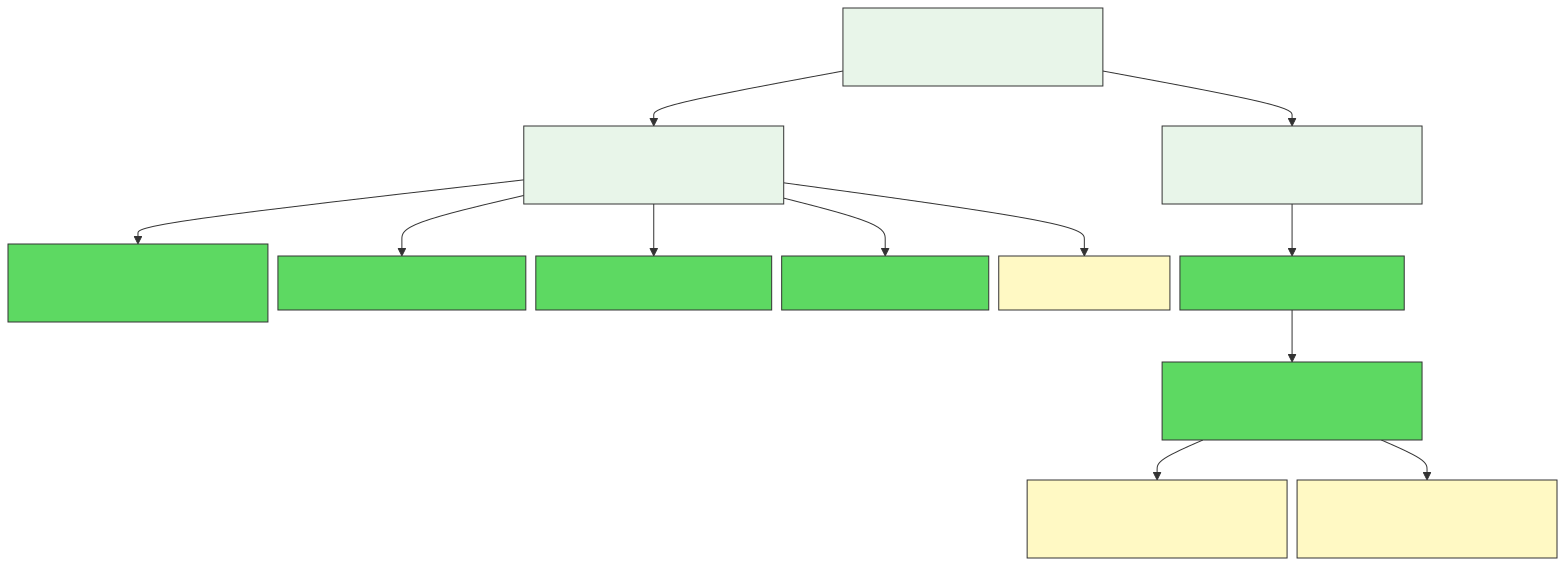

INFO:root:SVG file saved as /tmp/tmp6w29_2om.svg
INFO:root:Mermaid CLI executed successfully.


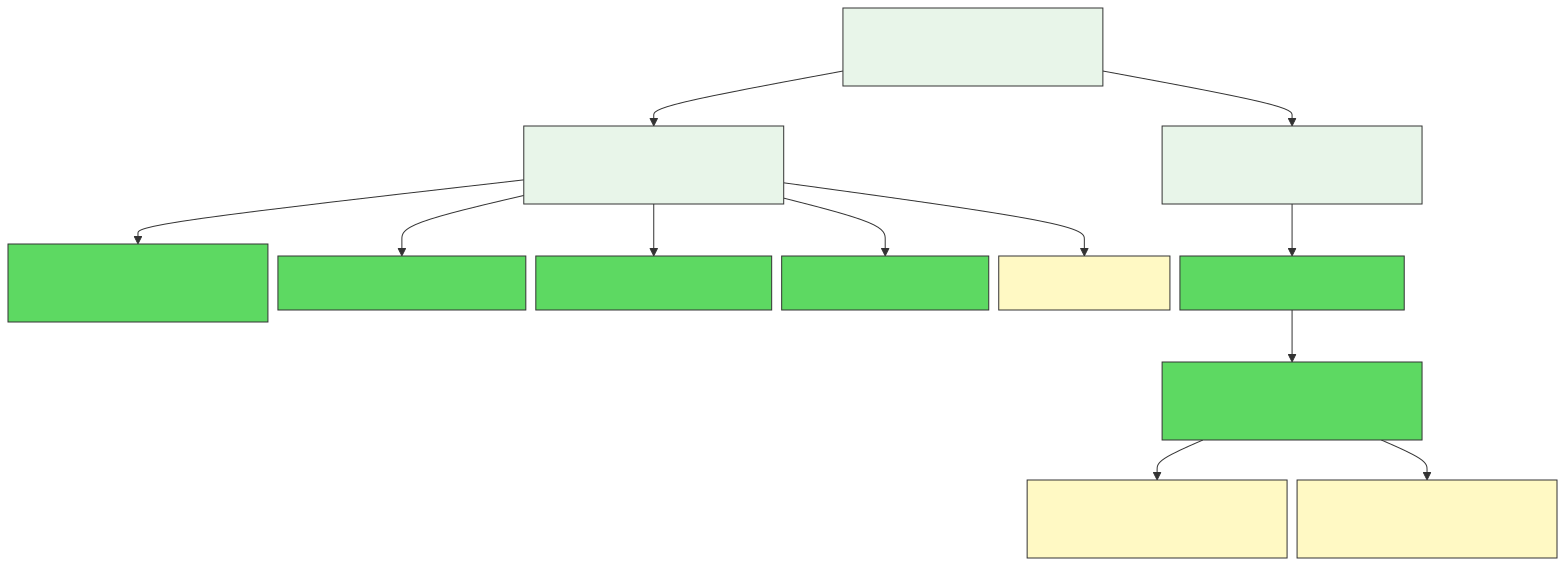

INFO:root:SVG file saved as ./files/mermaid_output.svg


In [8]:
### get svg
mermaid_code, mermaid_link, _ = get_mermaid_data(text_input, selected_prompt_for_diagram_creation, diagram_model, main_temperature,  review_code=False)
status = run_mermaid_cli(mermaid_code, streamlit_usage=False)
    

In [9]:
mermaid_link

'http://mermaid.live/edit#pako:eNqdk99v2jAQx/+VU6qMF5Da0k4jkyZBfkBLu1awt2UPVmyIVecc2c4gRfzvu2SEUvq0PVg625/72t/zeedlmgsvAM/3dxKlC2DXWym9yXJmXK+ZIQHLkmUS1zS/uuxDzzB8eVu6udzv976f4jEPfkxS9H2Yixqejc6EtcICQw6JRE5ZNsXxz9T7vkiuQSKEQqlKMQMzXQhtHbPSpt6vIAhKIwtm6hQnhC/EmihHUgvB9RYmTDHMxBkZEjnOnPzdkmN0Um8lZ+hgKlB0uszlG1bTPSLCI+GIWcmMEYwQ42tdfCRjIqeqcrRAlIBljS4Xb1c9gkljbRw9zxrzvMoa0XNmSkyoK3TCkJ2n5d99KzKNvLUxI2BZlaU2zsKjdDrLactIpiCp8FSzM35HGXRgoRvfTUaZs3V9fvA9UbGShcS2PhEr2Frwdyecp8wp5ZFJdDQsVUeYdf2++Cf3fmgfilyT+FNTeHoJqpUz1AQfYOqRUCOK1k7TFDAYfANqnkkbhPAJIhoxjaRbnHbYjIrUBnfkvQ3uyV4bzCnhoZVfulpRw6WYKWZtJFZwqBespFLBRfwluY1HfbDO6BcRXAyHw24y2Eju8uCq3PYh00qbdvfridTRyUEsSZJRePOfYl29D1q3nI8+X/+LltcHrxCmYJLTh9551JxF+7W5WLFKOW+//wOOtVa/'

## 2. Other diagrams creation - on AI actions (not graphical abstract)

In [9]:
graph_type = "State Diagram"
selected_prompt = graph_type_to_prompt.get(graph_type)
selected_prompt_for_diagram_creation = llm_prompts.get(selected_prompt)
print(selected_prompt_for_diagram_creation)

Create a Mermaid state diagram based on the provided text, ensuring it captures all the state transitions and details effectively. The diagram should be created using Mermaid markup language and should focus on accurately depicting the state changes described in the text.

**Key instructions:**
- Avoid using hyphens and special characters like brackets or parentheses in state names.
- Ensure no spaces at the end of lines.
- Begin the Mermaid code with \"stateDiagram\" and use state syntax on the second line.
- Do not use \"theme\" as the second line, nor comments starting with #.
- Use a clear and structured design with distinct state shapes. 
- Avoid using square brackets and round brackets one after another, it causes the error. Avoid using brackets if possible. 
- To define the color, use a class-based styling approach using 'classDef'.
- Maintain a logical and coherent style to enhance understanding.

# Steps
1. Analyze the provided text to identify key states and transitions.
2. S

In [10]:
mermaid_code_state_diagram, mermaid_link_state_diagram, _ = get_mermaid_data(text_input, selected_prompt_for_diagram_creation, diagram_model, main_temperature, review_code=False)

INFO:httpx:HTTP Request: POST https://dora-dev.openai.azure.com//openai/deployments/gpt-4o/chat/completions?api-version=2024-02-15-preview "HTTP/1.1 200 OK"


INFO:root:Mermaid CLI executed successfully.


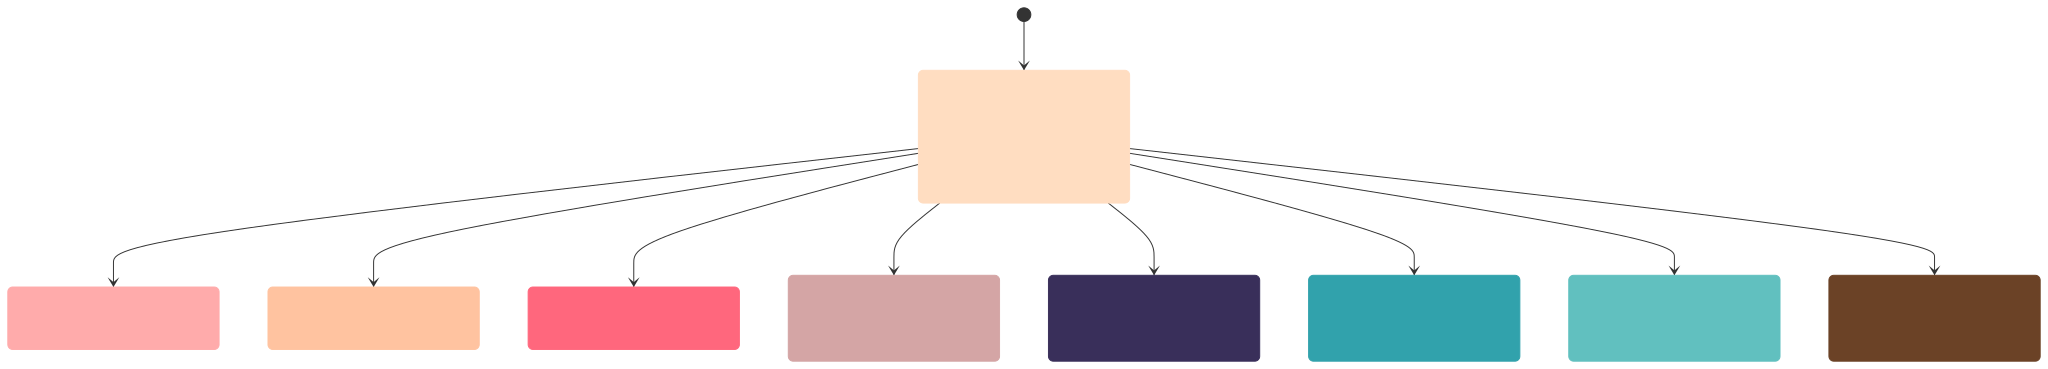

INFO:root:SVG file saved as ./files/mermaid_output.svg


In [11]:
run_mermaid_cli(mermaid_code_state_diagram, streamlit_usage=False)

In [12]:
mermaid_link_state_diagram

'http://mermaid.live/edit#pako:eNqNlVFv2yAQx78K8t6mVmqSJtU8aZITz+tLqqh7nPfAMHbQbIgAT82qfvcdOGAco6kPSXTx/eC4//3xa0JERZMUJUpjTXOGG4m7kpMWK5XTGmmJuSKSnTQTvMBEC4lq1rbph6LI893iRmkpflMXfg5QSSvxssUt5oR6Jttm24AxYcicpNCU8UfRUQEVKaY8uVtldwFpwpDsqMa/RMtI0XNiih3JzcNDHpAmDEnMIf2FVfB7GLZ3aH6frbO1R4cwRCuqgawZwWbHr/zvuaMOXn1aFuvMw0MYwk3bQ8+PANLvZ66PdDztapEts93I2jBkn7L88AjVVr096wXbLHZ328JjQzhpEtPidMTN2QHb++VyMwI2BKDkPz7+RLe3X9DTc7Esufm24XOoaQph07cwNypIOcwljCfu54rFE7OIQCnKgPlzlZlH9Yjnfou1P5563e141t43NzVN6IR9PCSkaCd7wnA7NRSqB0d1mHENH8YbRGjbQgskOgYdxLyCYaspr0wKbiBXaWSbAoVQBApSBbuF+qRoj5WmEoxoewr7iIsrw7VLPlcs0MFZcorMtQsR70VUu8clj6gY9PGqL1BoQ7nxElQdGNRVA+tFtf7vitT5E9acOrfksWl4Z3mBj5FyLMg+HZp3LmYpc8oLBq12YzVOVeBjLZDqTychtf2THAWvpJkz13kzgdb/1sqx+9w9n3g7vLxdQsTZ8/vaJUfcPb+iXXLM4ZFr2aXHbR69jB0SdXvsBvbduvL8VeyP6ZXwmiQ3KOmoBE9X8GJ9TWDdzr5iwcC4b3Xy9vYPzXa67w=='

## 3. AI actions on the created graph

In [13]:
from langchain.schema import HumanMessage, SystemMessage, AIMessage
from langchain_community.chat_message_histories import ChatMessageHistory

assistant_prompt = llm_prompts.get("assistant_prompt")
assistant_prompt = assistant_prompt.replace("{context}", text_input)
assistant_prompt = assistant_prompt.replace("{mermaid_code}", mermaid_code_state_diagram)

In [15]:
history = []
if not history:
    history.append(SystemMessage(content=assistant_prompt))
followup_temperature = 0.2
diagram_followup_model = "gpt-4o"

INFO:root:Mermaid CLI executed successfully.


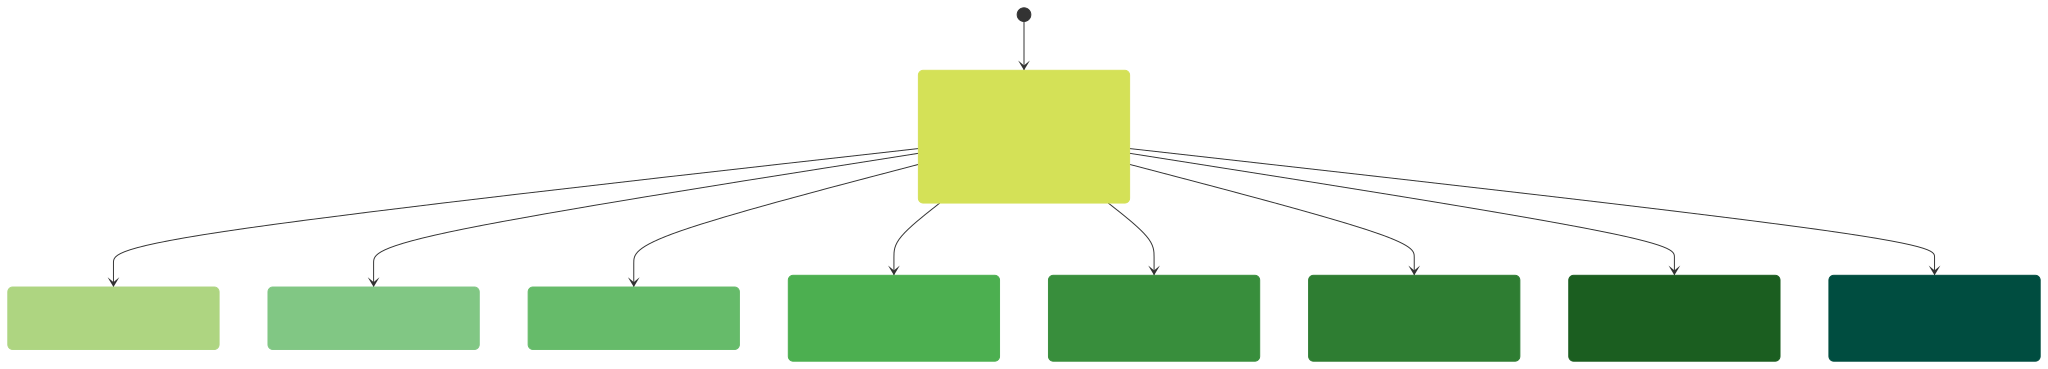

INFO:root:SVG file saved as ./files/mermaid_output.svg


In [17]:
### User 1 question
user_prompt1 = "Make the diagram in green colors"
history.append(HumanMessage(content=user_prompt1)) 

mermaid_code_updated, mermaid_link_updated, _ = get_mermaid_data(user_prompt1, assistant_prompt, "gpt-4o", 0.2, review_code=False, user_history=True, history = history)
history.append(AIMessage(content=mermaid_code_updated))

run_mermaid_cli(mermaid_code_updated, streamlit_usage=False)

In [20]:
history

[SystemMessage(content="You are an assistant that creates Mermaid.js diagrams. You are provided a text based on which the diagram is created and a mermaid diagram from the user. Your main task is to apply changes asked by the user to the mermaid.js code and output only the updated code, nothing else. \n#User's text\n1. Nuclear factor erythroid 2-related factor 2 (NRF2) is a crucial transcription factor that maintains cellular homeostasis and defends against oxidative stress.\n   \n2. NRF2 regulates redox balance, protein homeostasis, and metabolic functions, acting as a master regulator of redox homeostasis.\n\n3. NRF2 activates transcription of genes for antioxidant proteins, enzymes for detoxification, glutathione synthesis, and NADPH production, crucial for ROS neutralization and cellular redox balance.\n\n4. Additionally, NRF2 supports mitochondrial function by promoting mitophagy, removing damaged mitochondria to ensure cellular energy balance and reduce oxidative stress.\n#User's

INFO:httpx:HTTP Request: POST https://dora-dev.openai.azure.com//openai/deployments/gpt-4o/chat/completions?api-version=2024-02-15-preview "HTTP/1.1 200 OK"
INFO:root:Mermaid CLI executed successfully.


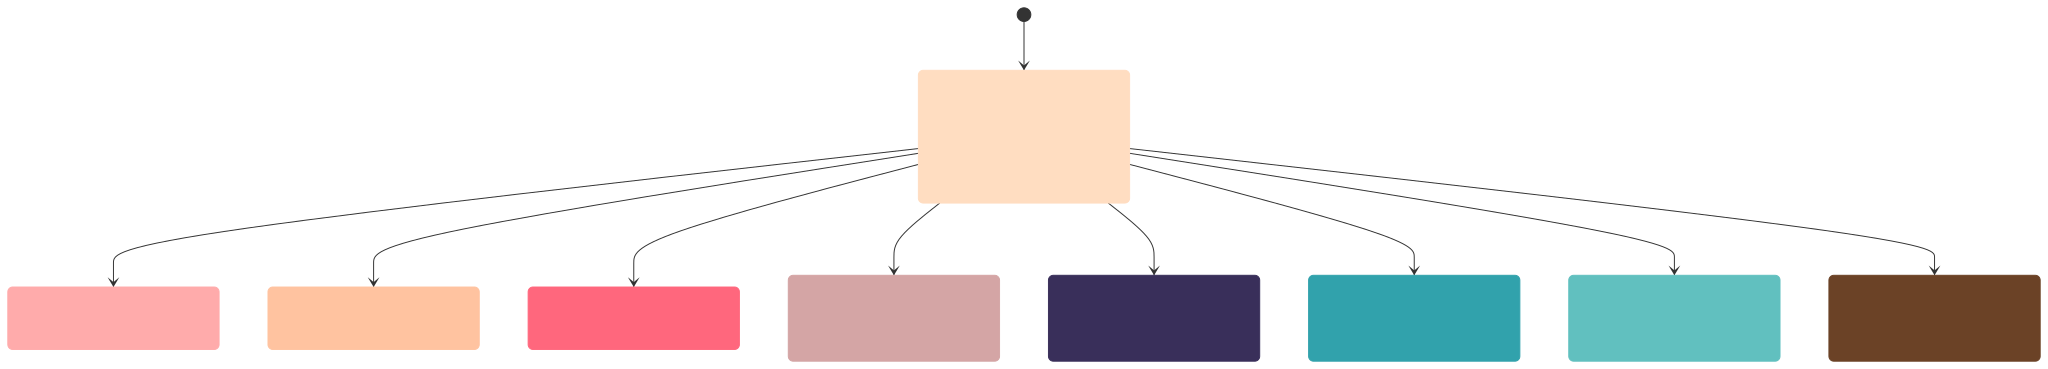

INFO:root:SVG file saved as ./files/mermaid_output.svg


In [21]:
### User 2 question
user_prompt2 = "I do not like this version. Give me the initial diagram"
history.append(HumanMessage(content=user_prompt2)) 

mermaid_code_updated, mermaid_link_updated, _ = get_mermaid_data(user_prompt2, assistant_prompt, "gpt-4o", 0.2, review_code=False, user_history=True, history = history)
history.append(AIMessage(content=mermaid_code_updated))
run_mermaid_cli(mermaid_code_updated, streamlit_usage=False)

In [22]:
history

[SystemMessage(content="You are an assistant that creates Mermaid.js diagrams. You are provided a text based on which the diagram is created and a mermaid diagram from the user. Your main task is to apply changes asked by the user to the mermaid.js code and output only the updated code, nothing else. \n#User's text\n1. Nuclear factor erythroid 2-related factor 2 (NRF2) is a crucial transcription factor that maintains cellular homeostasis and defends against oxidative stress.\n   \n2. NRF2 regulates redox balance, protein homeostasis, and metabolic functions, acting as a master regulator of redox homeostasis.\n\n3. NRF2 activates transcription of genes for antioxidant proteins, enzymes for detoxification, glutathione synthesis, and NADPH production, crucial for ROS neutralization and cellular redox balance.\n\n4. Additionally, NRF2 supports mitochondrial function by promoting mitophagy, removing damaged mitochondria to ensure cellular energy balance and reduce oxidative stress.\n#User's